# 05 Resistance Genes By Group

Notebook canónico. Los datos se leen de `data/processed/` y los productos derivados se guardan en `results/`.


In [1]:
# Canonical notebook setup
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.microbiome_analysis.paths import DATASETS_DIR, analysis_output_dirs

ANALYSIS = '05_resistance_genes_by_group'
OUTPUTS = analysis_output_dirs(ANALYSIS)
RESISTANCE_TABLES = OUTPUTS['tables']
# Guardar figuras nuevas en OUTPUTS['figures'] y tablas en OUTPUTS['tables'].


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [3]:
metadata = pd.read_csv(DATASETS_DIR / 'latinbiota_sample_metadata.csv')
data = pd.read_csv(DATASETS_DIR / 'rgi_annotation_all_bins.tsv', sep = '\t')

In [4]:
data.columns

Index(['ORF_ID', 'Contig', 'Start', 'Stop', 'Orientation', 'Cut_Off',
       'Pass_Bitscore', 'Best_Hit_Bitscore', 'Best_Hit_ARO', 'Best_Identities',
       'ARO', 'Model_type', 'SNPs_in_Best_Hit_ARO', 'Other_SNPs', 'Drug Class',
       'Resistance Mechanism', 'AMR Gene Family', 'Predicted_DNA',
       'Predicted_Protein', 'CARD_Protein_Sequence',
       'Percentage Length of Reference Sequence', 'ID', 'Model_ID', 'Nudged',
       'Note', 'Hit_Start', 'Hit_End', 'Antibiotic', 'Sample', 'BIN',
       'Species'],
      dtype='object')

In [5]:
# data.to_csv(RESISTANCE_TABLES / 'resistance.csv', index=False)

In [6]:
data['Antibiotic']

0                                              vancomycin
1                                              vancomycin
2       tetracycline; doxycycline; minocycline; chlort...
3       erythromycin; roxithromycin; lincomycin; telit...
4                                            tetracycline
                              ...                        
7438                                           vancomycin
7439                                           vancomycin
7440                                           vancomycin
7441                                           vancomycin
7442                                           vancomycin
Name: Antibiotic, Length: 7443, dtype: object

In [7]:
data_strict = data[data['Cut_Off'] == 'Strict']

In [8]:
data_strict.columns

Index(['ORF_ID', 'Contig', 'Start', 'Stop', 'Orientation', 'Cut_Off',
       'Pass_Bitscore', 'Best_Hit_Bitscore', 'Best_Hit_ARO', 'Best_Identities',
       'ARO', 'Model_type', 'SNPs_in_Best_Hit_ARO', 'Other_SNPs', 'Drug Class',
       'Resistance Mechanism', 'AMR Gene Family', 'Predicted_DNA',
       'Predicted_Protein', 'CARD_Protein_Sequence',
       'Percentage Length of Reference Sequence', 'ID', 'Model_ID', 'Nudged',
       'Note', 'Hit_Start', 'Hit_End', 'Antibiotic', 'Sample', 'BIN',
       'Species'],
      dtype='object')

In [9]:
antibiotics_set = set()
for antibiotics in list(data_strict['Drug Class']):
    # print(antibiotics)
    try:
        for antibiotic in antibiotics.split('; '):
            antibiotics_set.add(antibiotic)
    except:
        continue
        # antibiotics_set.add(antibiotic)
    

In [10]:
len(antibiotics_set)

31

In [11]:
data.columns

Index(['ORF_ID', 'Contig', 'Start', 'Stop', 'Orientation', 'Cut_Off',
       'Pass_Bitscore', 'Best_Hit_Bitscore', 'Best_Hit_ARO', 'Best_Identities',
       'ARO', 'Model_type', 'SNPs_in_Best_Hit_ARO', 'Other_SNPs', 'Drug Class',
       'Resistance Mechanism', 'AMR Gene Family', 'Predicted_DNA',
       'Predicted_Protein', 'CARD_Protein_Sequence',
       'Percentage Length of Reference Sequence', 'ID', 'Model_ID', 'Nudged',
       'Note', 'Hit_Start', 'Hit_End', 'Antibiotic', 'Sample', 'BIN',
       'Species'],
      dtype='object')

In [12]:
data_strict['Resistance Mechanism'].unique()

array(['antibiotic target alteration', 'antibiotic target protection',
       'antibiotic efflux', 'antibiotic inactivation',
       'antibiotic target alteration; antibiotic efflux',
       'antibiotic target alteration; antibiotic efflux; reduced permeability to antibiotic',
       'antibiotic target alteration; antibiotic target replacement',
       'antibiotic target replacement',
       'antibiotic efflux; reduced permeability to antibiotic',
       'reduced permeability to antibiotic'], dtype=object)

In [13]:
data_final = {}

In [14]:
for antibiotic in antibiotics_set:
    for sample in list(data_strict['Sample'].unique()):
        if sample not in data_final:
            data_final[sample] = set()
        for anti in list(data_strict[data_strict['Sample'] == sample]['Drug Class']):
        # for anti in list(data_strict[data_strict['Sample'] == sample]['Resistance Mechanism']):
            try:
                if antibiotic in anti.split('; '):
                    data_final[sample].add(antibiotic)
            except:
                continue
                

In [15]:
data_final

{'37035_7#10': {'glycopeptide antibiotic',
  'lincosamide antibiotic',
  'macrolide antibiotic',
  'streptogramin A antibiotic',
  'streptogramin B antibiotic',
  'streptogramin antibiotic',
  'tetracycline antibiotic'},
 '37035_2#13': {'aminoglycoside antibiotic',
  'cephamycin',
  'disinfecting agents and antiseptics',
  'fluoroquinolone antibiotic',
  'glycopeptide antibiotic',
  'lincosamide antibiotic',
  'macrolide antibiotic',
  'nitroimidazole antibiotic',
  'streptogramin A antibiotic',
  'streptogramin B antibiotic',
  'streptogramin antibiotic',
  'tetracycline antibiotic'},
 '37082_2#19': {'aminocoumarin antibiotic',
  'aminoglycoside antibiotic',
  'carbapenem',
  'cephalosporin',
  'cephamycin',
  'disinfecting agents and antiseptics',
  'elfamycin antibiotic',
  'fluoroquinolone antibiotic',
  'glycopeptide antibiotic',
  'glycylcycline',
  'macrolide antibiotic',
  'monobactam',
  'nitroimidazole antibiotic',
  'nucleoside antibiotic',
  'penam',
  'penem',
  'peptide a

In [16]:
# build a list of (sample, antibiotic) pairs
rows = []
for sample, antibiotics in data_final.items():
    for ab in antibiotics:
        rows.append((sample, ab))

# create a DataFrame from those pairs
df = pd.DataFrame(rows, columns=['sample', 'antibiotic'])

# pivot to wide format with presence (1/0)
presence_df = (
    df.assign(presence=1)
      .pivot_table(index='antibiotic', columns='sample', values='presence', fill_value=0)
      .astype(int)
)

presence_df

sample,36703_3#1,36703_3#10,36703_3#12,36703_3#13,36703_3#14,36703_3#15,36703_3#16,36703_3#17,36703_3#18,36703_3#19,...,37082_3#3,37082_3#30,37082_3#31,37082_3#32,37082_3#4,37082_3#5,37082_3#6,37082_3#7,37082_3#8,37082_3#9
antibiotic,,,,,,,,,,,,,,,,,,,,,
aminocoumarin antibiotic,0,0,1,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,1
aminoglycoside antibiotic,0,0,1,0,0,0,0,0,1,1,...,1,0,0,0,0,0,0,0,0,1
carbapenem,0,0,1,0,0,0,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
cephalosporin,0,0,1,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,1
cephamycin,0,0,1,0,0,0,0,0,1,0,...,1,0,0,1,1,0,0,0,0,1
diaminopyrimidine antibiotic,0,0,1,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,1
disinfecting agents and antiseptics,1,0,1,0,0,0,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
elfamycin antibiotic,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
fluoroquinolone antibiotic,1,1,1,0,0,0,1,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [17]:
data.head()

,ORF_ID,Contig,Start,Stop,Orientation,Cut_Off,Pass_Bitscore,Best_Hit_Bitscore,Best_Hit_ARO,Best_Identities,...,ID,Model_ID,Nudged,Note,Hit_Start,Hit_End,Antibiotic,Sample,BIN,Species
0,KFJKFKDA_00325 hypothetical protein,NaN,NaN,NaN,NaN,Strict,50,81.3,vanY gene in vanB cluster,29.90,...,gnl|BL_ORD_ID|603|hsp_num:0,556,NaN,NaN,NaN,NaN,vancomycin,37035_7#10,37035_7#10.001,Ruminococcus_E bromii_B
1,KFJKFKDA_00880 Alanine racemase 1,NaN,NaN,NaN,NaN,Strict,175,269.6,vanT gene in vanG cluster,39.04,...,gnl|BL_ORD_ID|1523|hsp_num:0,1561,NaN,NaN,NaN,NaN,vancomycin,37035_7#10,37035_7#10.001,Ruminococcus_E bromii_B
2,"KFJKFKDA_01317 Elongation factor G, mitochondrial",NaN,NaN,NaN,NaN,Strict,300,300.1,tet(Q),29.80,...,gnl|BL_ORD_ID|1220|hsp_num:0,1183,NaN,NaN,NaN,NaN,tetracycline; doxycycline; minocycline; chlort...,37035_7#10,37035_7#10.001,Ruminococcus_E bromii_B
3,KFJKFKDA_01630 rRNA adenine N-6-methyltransferase,NaN,NaN,NaN,NaN,Strict,400,477.6,ErmB,98.78,...,gnl|BL_ORD_ID|1425|hsp_num:0,1549,NaN,NaN,NaN,NaN,erythromycin; roxithromycin; lincomycin; telit...,37035_7#10,37035_7#10.001,Ruminococcus_E bromii_B
4,JCFDOLGH_00629 Efflux pump membrane transporte...,NaN,NaN,NaN,NaN,Strict,750,776.2,adeF,42.03,...,gnl|BL_ORD_ID|133|hsp_num:0,153,NaN,NaN,NaN,NaN,tetracycline,37035_2#13,37035_2#13.010,Alistipes putredinis


In [18]:
import pandas as pd
import numpy as np


print("--- 1. DataFrame Original (data_strict) ---")
# print(data_strict)
print("\n")


# --- 2. Crear el DataFrame de Conteo ---

# (a) Seleccionar solo las columnas necesarias
#     y eliminar filas donde la 'Drug Class' es nula
df_long = data_strict[['Sample', 'Drug Class']].dropna(subset=['Drug Class'])

# (b) Separar las clases de f&aacute;rmacos en una lista
df_long['Atomic_Class'] = df_long['Drug Class'].str.split('; ')

# (c) "Explotar" las listas en filas separadas
#     Esta es la operaci&oacute;n clave. Una fila con ['A', 'B'] se convierte en dos filas.
df_long = df_long.explode('Atomic_Class')

# (d) Limpiar espacios en blanco
df_long['Atomic_Class'] = df_long['Atomic_Class'].str.strip()

print("--- 2. DataFrame 'explotado' (formato largo) ---")
# print(df_long)
print("\n")

# (e) Agrupar por Muestra (Sample) y Clase (Atomic_Class) y contar el tama&ntilde;o
#     .size() cuenta cu&aacute;ntas filas (bins) caen en cada grupo
df_counts_series = df_long.groupby(['Sample', 'Atomic_Class']).size()

print("--- 3. Series de Conteo (formato largo) ---")
# print(df_counts_series)
print("\n")

# (f) Pivotar (Unstack) para obtener el formato deseado
#     Ponemos 'Sample' en las columnas y llenamos con 0 si no hay conteo
count_df = df_counts_series.unstack(level='Sample', fill_value=0)

# (g) Limpieza final para que coincida con tu formato
count_df.index.name = 'antibiotic'
count_df.columns.name = 'sample'

print("--- 4. DataFrame Final de Conteo ---")
count_df

--- 1. DataFrame Original (data_strict) ---


--- 2. DataFrame 'explotado' (formato largo) ---


--- 3. Series de Conteo (formato largo) ---


--- 4. DataFrame Final de Conteo ---


sample,36703_3#1,36703_3#10,36703_3#12,36703_3#13,36703_3#14,36703_3#15,36703_3#16,36703_3#17,36703_3#18,36703_3#19,...,37082_3#3,37082_3#30,37082_3#31,37082_3#32,37082_3#4,37082_3#5,37082_3#6,37082_3#7,37082_3#8,37082_3#9
antibiotic,,,,,,,,,,,,,,,,,,,,,
aminocoumarin antibiotic,0,0,3,0,0,0,0,0,1,0,...,3,0,0,0,0,0,0,0,0,4
aminoglycoside antibiotic,0,0,5,0,0,0,0,0,4,1,...,8,0,0,0,0,0,0,0,0,4
carbapenem,0,0,2,0,0,0,0,0,2,0,...,6,0,0,1,0,0,0,0,0,2
cephalosporin,0,0,10,0,0,0,0,0,13,0,...,18,0,0,0,0,1,0,0,0,10
cephamycin,0,0,5,0,0,0,0,0,7,0,...,8,0,0,1,1,0,0,0,0,4
diaminopyrimidine antibiotic,0,0,1,0,0,0,0,0,2,0,...,2,0,0,0,0,0,0,0,0,1
disinfecting agents and antiseptics,2,0,11,0,0,0,0,0,13,0,...,18,0,0,1,0,0,0,0,0,12
elfamycin antibiotic,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
fluoroquinolone antibiotic,1,1,14,0,0,0,1,0,16,0,...,23,0,0,2,0,2,0,0,0,12


In [19]:
count_df.to_csv(RESISTANCE_TABLES / 'resistance_antibiotic_class_counts.csv')

In [20]:
df_long = data_strict[['Sample', 'Drug Class', 'Species']].dropna()

# (b) Separar las clases de f&aacute;rmacos en una lista
df_long['Atomic_Class'] = df_long['Drug Class'].str.split('; ')

# (c) "Explotar" las listas en filas separadas
df_long = df_long.explode('Atomic_Class')

# (d) Limpiar espacios en blanco
df_long['Atomic_Class'] = df_long['Atomic_Class'].str.strip()

print("--- 2. DataFrame 'explotado' (formato largo) ---")
# print(df_long)
print("\n")

# (e) ¡¡CAMBIO CLAVE!! Agrupar por TRES columnas
#     Contar&aacute; los bins para cada combinaci&oacute;n (Muestra, Clase, Especie)
df_counts_series = df_long.groupby(['Sample', 'Atomic_Class', 'Species']).size()

# (f) Convertir la serie a un DataFrame largo y renombrar el conteo
df_long_counts = df_counts_series.reset_index(name='count')

print("--- 3. DataFrame de conteos (formato largo) ---")
# print(df_long_counts)
print("\n")

# --- 4. A&ntilde;adir 'lifestyle' desde los metadatos ---
# df_final_for_plot = pd.merge(
#     df_long_counts, 
#     metadata_df, 
#     on='Sample'
# )

# Renombrar 'Atomic_Class' para que coincida con el gr&aacute;fico anterior
df_final_for_plot = df_long_counts.rename(columns={'Atomic_Class': 'drug class'})

print("--- 4. DataFrame FINAL listo para el heatmap ---")
df_final_for_plot

--- 2. DataFrame 'explotado' (formato largo) ---


--- 3. DataFrame de conteos (formato largo) ---


--- 4. DataFrame FINAL listo para el heatmap ---


,Sample,drug class,Species,count
0,36703_3#1,disinfecting agents and antiseptics,Akkermansia sp004167605,1
1,36703_3#1,disinfecting agents and antiseptics,Phascolarctobacterium faecium,1
2,36703_3#1,fluoroquinolone antibiotic,Alistipes putredinis,1
3,36703_3#1,glycopeptide antibiotic,Agathobacter faecis,2
4,36703_3#1,glycopeptide antibiotic,Alistipes putredinis,1
...,...,...,...,...
3549,37082_3#9,phenicol antibiotic,Escherichia coli,7
3550,37082_3#9,phosphonic acid antibiotic,Escherichia coli,2
3551,37082_3#9,rifamycin antibiotic,Bifidobacterium pseudocatenulatum,1
3552,37082_3#9,rifamycin antibiotic,Escherichia coli,7


In [21]:
labels_fp = []
for item in df_final_for_plot.Sample:
    labels_fp.append(metadata[metadata['Lane'] == item]['Lifestyle'].iloc[0])

In [22]:
df_final_for_plot['Lifestyle'] = labels_fp

In [23]:
rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']

In [24]:
presence_df = count_df[[x for x in count_df.columns if x not in rare]]

In [25]:
presence_df.head()

sample,36703_3#1,36703_3#10,36703_3#12,36703_3#13,36703_3#14,36703_3#15,36703_3#16,36703_3#17,36703_3#18,36703_3#19,...,37082_3#3,37082_3#30,37082_3#31,37082_3#32,37082_3#4,37082_3#5,37082_3#6,37082_3#7,37082_3#8,37082_3#9
antibiotic,,,,,,,,,,,,,,,,,,,,,
aminocoumarin antibiotic,0,0,3,0,0,0,0,0,1,0,...,3,0,0,0,0,0,0,0,0,4
aminoglycoside antibiotic,0,0,5,0,0,0,0,0,4,1,...,8,0,0,0,0,0,0,0,0,4
carbapenem,0,0,2,0,0,0,0,0,2,0,...,6,0,0,1,0,0,0,0,0,2
cephalosporin,0,0,10,0,0,0,0,0,13,0,...,18,0,0,0,0,1,0,0,0,10
cephamycin,0,0,5,0,0,0,0,0,7,0,...,8,0,0,1,1,0,0,0,0,4


In [26]:
presence_df.index

Index(['aminocoumarin antibiotic', 'aminoglycoside antibiotic', 'carbapenem',
       'cephalosporin', 'cephamycin', 'diaminopyrimidine antibiotic',
       'disinfecting agents and antiseptics', 'elfamycin antibiotic',
       'fluoroquinolone antibiotic', 'glycopeptide antibiotic',
       'glycylcycline', 'lincosamide antibiotic', 'macrolide antibiotic',
       'monobactam', 'mupirocin-like antibiotic', 'nitrofuran antibiotic',
       'nitroimidazole antibiotic', 'nucleoside antibiotic',
       'oxazolidinone antibiotic', 'penam', 'penem', 'peptide antibiotic',
       'phenicol antibiotic', 'phosphonic acid antibiotic',
       'pleuromutilin antibiotic', 'rifamycin antibiotic',
       'streptogramin A antibiotic', 'streptogramin B antibiotic',
       'streptogramin antibiotic', 'sulfonamide antibiotic',
       'tetracycline antibiotic'],
      dtype='object', name='antibiotic')

In [27]:
presence_df = presence_df.T

In [28]:
labels = []
for item in presence_df.index:
    labels.append(metadata[metadata['Lane'] == item]['Lifestyle'].iloc[0])

In [29]:
presence_df['label'] = labels

In [30]:
presence_df

antibiotic,aminocoumarin antibiotic,aminoglycoside antibiotic,carbapenem,cephalosporin,cephamycin,diaminopyrimidine antibiotic,disinfecting agents and antiseptics,elfamycin antibiotic,fluoroquinolone antibiotic,glycopeptide antibiotic,...,phenicol antibiotic,phosphonic acid antibiotic,pleuromutilin antibiotic,rifamycin antibiotic,streptogramin A antibiotic,streptogramin B antibiotic,streptogramin antibiotic,sulfonamide antibiotic,tetracycline antibiotic,label
sample,,,,,,,,,,,,,,,,,,,,,
36703_3#1,0,0,0,0,0,0,2,0,1,36,...,1,0,0,0,0,0,0,0,3,Urban
36703_3#10,0,0,0,0,0,0,0,0,1,20,...,0,0,0,2,2,2,2,0,6,Urban
36703_3#12,3,5,2,10,5,1,11,1,14,42,...,8,0,0,8,0,0,0,0,10,Rural
36703_3#13,0,0,0,0,0,0,0,0,0,20,...,0,0,0,0,0,0,0,0,3,Rural
36703_3#14,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,Rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5,0,0,0,1,0,0,0,0,2,10,...,0,0,0,1,0,0,0,0,4,Rural
37082_3#6,0,0,0,0,0,0,0,0,0,36,...,0,0,0,1,0,0,0,0,1,Rural
37082_3#7,0,0,0,0,0,0,0,0,0,32,...,0,0,0,0,0,0,0,0,2,Rural


In [31]:
from scipy.stats import chi2_contingency, fisher_exact

In [32]:
features_to_test = [col for col in presence_df.columns if col != 'label']

# Lista para guardar los resultados
results = []

# --- 3. Iterar y Probar ---
print("Ejecutando pruebas...\n")
for feature in features_to_test:
    
    # (a) Crear la tabla de contingencia 2x2
    # Esto cuenta las combinaciones de [Grupo] vs [Presencia/Ausencia]
    contingency_table = pd.crosstab(presence_df['label'], presence_df[feature])
    
    # Opcional: imprimir la tabla para verificar
    # print(f"--- Tabla para {feature} ---")
    # print(contingency_table)
    # print("\n")

    # (b) Aplicar la prueba Chi-cuadrada
    # g, p, dof, exp = chi2_contingency(contingency_table)
    # Nota: Usamos 'correction=True' (Corrección de Yates) que es más 
    # conservadora y recomendada para tablas 2x2.
    try:
        chi2, p_chi2, dof, expected = chi2_contingency(contingency_table, correction=True)
        
        # (c) [RECOMENDADO] Aplicar la Prueba Exacta de Fisher
        # Es más precisa para conteos bajos.
        odds_ratio, p_fisher = fisher_exact(contingency_table)

        # (d) Guardar resultados
        results.append({
            'feature': feature,
            'chi2_stat': chi2,
            'p_value_chi2': p_chi2,
            'p_value_fisher': p_fisher
        })
    except ValueError as e:
        # Esto puede pasar si una columna es toda 0s o toda 1s
        print(f"No se pudo calcular la prueba para {feature}: {e}")
        results.append({
            'feature': feature,
            'chi2_stat': None,
            'p_value_chi2': None,
            'p_value_fisher': None
        })


# --- 4. Ver Resultados ---
# Convertir la lista de resultados en un DataFrame limpio
chi2_results_df = pd.DataFrame(results)
chi2_results_df

Ejecutando pruebas...

No se pudo calcular la prueba para aminocoumarin antibiotic: The input `table` must be of shape (2, 2).
No se pudo calcular la prueba para aminoglycoside antibiotic: The input `table` must be of shape (2, 2).
No se pudo calcular la prueba para carbapenem: The input `table` must be of shape (2, 2).
No se pudo calcular la prueba para cephalosporin: The input `table` must be of shape (2, 2).
No se pudo calcular la prueba para cephamycin: The input `table` must be of shape (2, 2).
No se pudo calcular la prueba para diaminopyrimidine antibiotic: The input `table` must be of shape (2, 2).
No se pudo calcular la prueba para disinfecting agents and antiseptics: The input `table` must be of shape (2, 2).
No se pudo calcular la prueba para elfamycin antibiotic: The input `table` must be of shape (2, 2).
No se pudo calcular la prueba para fluoroquinolone antibiotic: The input `table` must be of shape (2, 2).
No se pudo calcular la prueba para glycopeptide antibiotic: The in

,feature,chi2_stat,p_value_chi2,p_value_fisher
0,aminocoumarin antibiotic,NaN,NaN,NaN
1,aminoglycoside antibiotic,NaN,NaN,NaN
2,carbapenem,NaN,NaN,NaN
3,cephalosporin,NaN,NaN,NaN
4,cephamycin,NaN,NaN,NaN
5,diaminopyrimidine antibiotic,NaN,NaN,NaN
6,disinfecting agents and antiseptics,NaN,NaN,NaN
7,elfamycin antibiotic,NaN,NaN,NaN
8,fluoroquinolone antibiotic,NaN,NaN,NaN
9,glycopeptide antibiotic,NaN,NaN,NaN


In [33]:
from scipy.stats import mannwhitneyu

# --- 2. Preparaci&oacute;n ---
# Lista de columnas a probar (todas excepto 'label')
features_to_test = [col for col in presence_df.columns if col != 'label']

# Lista para guardar los resultados
results = []

# Identificar los dos grupos &uacute;nicos
unique_groups = presence_df['label'].unique()
if len(unique_groups) != 2:
    print(f"Error: Se esperaban 2 grupos en 'label', pero se encontraron {len(unique_groups)}")
    # Aqu&iacute; podr&iacute;as detener el script si es necesario
else:
    group1_name = unique_groups[0] # Ej. 'Urban'
    group2_name = unique_groups[1] # Ej. 'Rural'
    
    print(f"Ejecutando pruebas Mann-Whitney U entre: {group1_name} vs {group2_name}\n")

    # --- 3. Iterar y Probar ---
    for feature in features_to_test:
        
        # (a) Extraer los datos de conteo para cada grupo
        # Esto reemplaza a pd.crosstab()
        group1_counts = presence_df[presence_df['label'] == group1_name][feature]
        group2_counts = presence_df[presence_df['label'] == group2_name][feature]
        
        # (b) Aplicar la prueba Mann-Whitney U
        try:
            # 'alternative='two-sided'' (para H1: Grupo1 != Grupo2)
            stat, p_value = mannwhitneyu(group1_counts, group2_counts, 
                                         alternative='two-sided')
            
            # (c) Guardar resultados (incluir medianas es buena pr&aacute;ctica)
            results.append({
                'feature': feature,
                'statistic_U': stat,
                'p_value': p_value,
                f'median_{group1_name}': group1_counts.median(),
                f'median_{group2_name}': group2_counts.median()
            })
        
        except ValueError as e:
            # Esto puede pasar si un grupo tiene varianza cero (ej. todos 0s)
            # y el test no se puede calcular.
            print(f"No se pudo calcular la prueba para {feature}: {e}")
            results.append({
                'feature': feature,
                'statistic_U': None,
                'p_value': None, # O puedes poner 1.0 si lo consideras "sin diferencia"
                f'median_{group1_name}': group1_counts.median(),
                f'median_{group2_name}': group2_counts.median()
            })


    # --- 4. Ver Resultados ---
    # Convertir la lista de resultados en un DataFrame limpio
    results_df = pd.DataFrame(results)
    
    # Ordenar por p-value para ver los m&aacute;s significativos
    results_df = results_df.sort_values('p_value')

Ejecutando pruebas Mann-Whitney U entre: Urban vs Rural



In [34]:
results_df[results_df['p_value'] < 0.05]

,feature,statistic_U,p_value,median_Urban,median_Rural
28,streptogramin antibiotic,6967.5,3.185869e-13,0.0,0.0
27,streptogramin B antibiotic,6908.0,9.244527e-13,0.0,0.0
26,streptogramin A antibiotic,6908.0,9.244527e-13,0.0,0.0
11,lincosamide antibiotic,7097.0,6.569715e-11,1.0,0.0
9,glycopeptide antibiotic,6912.5,1.879741e-07,25.0,17.0
30,tetracycline antibiotic,6338.5,1.413258e-04,4.0,2.0
12,macrolide antibiotic,6204.0,1.619100e-04,1.0,0.0
8,fluoroquinolone antibiotic,5720.5,1.297452e-02,1.0,0.0


C:\Users\rafap\AppData\Local\Temp\ipykernel_21916\2156274135.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


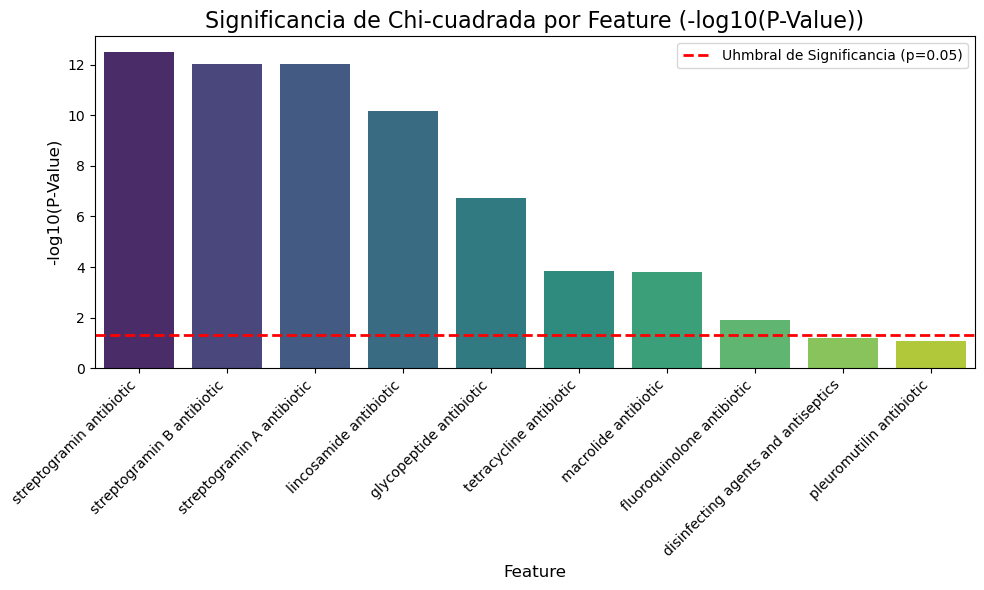

In [35]:

results_aux = results_df[results_df['p_value'] < 0.15]
plot_df = results_aux.dropna(subset=['p_value']).copy()

# Definimos el umbral de significancia
p_threshold = 0.05

plot_df = results_aux.dropna(subset=['p_value']).copy()

# Manejar p-values de 0: reemplazarlos por el número más pequeño posible
# Esto es crucial para que -log10 no dé infinito
plot_df.loc[plot_df['p_value'] == 0, 'p_value'] = np.finfo(float).eps

# Calculamos el -log10(p)
plot_df['neg_log10_p'] = -np.log10(plot_df['p_value'])

# Definimos el umbral de significancia (p=0.05)
p_threshold = 0.05
log_threshold = -np.log10(p_threshold)

# Ordenamos las barras por el valor -log10(p) (de más a menos significativo)
plot_df_sorted = plot_df.sort_values('neg_log10_p', ascending=False)


# --- 3. Crear el Gráfico ---
plt.figure(figsize=(10, 6))

barplot = sns.barplot(
    x='feature',
    y='neg_log10_p',
    data=plot_df_sorted,
    palette='viridis'
)

# Añadir la línea de significancia
barplot.axhline(
    y=log_threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Uhmbral de Significancia (p={p_threshold})'
)

# --- 4. Añadir Títulos y Etiquetas ---
plt.title('Significancia de Chi-cuadrada por Feature (-log10(P-Value))', fontsize=16)
plt.ylabel('-log10(P-Value)', fontsize=12)
plt.xlabel('Feature', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

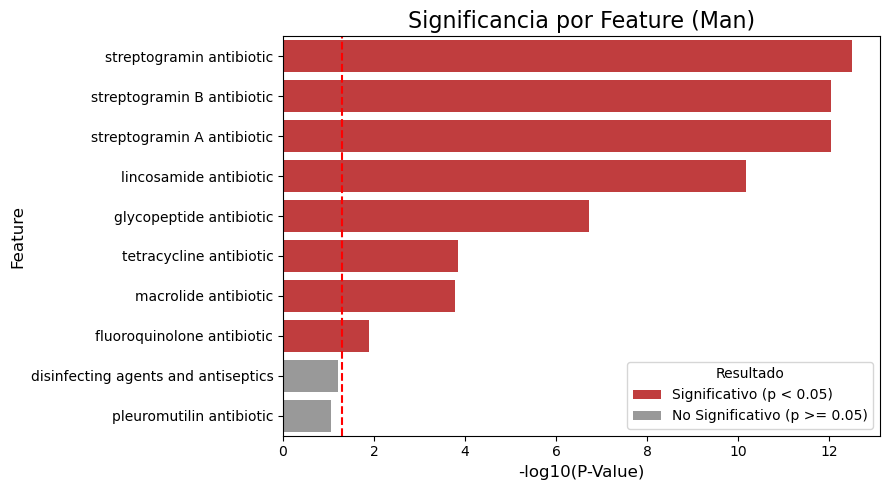

In [36]:
# Copiamos para evitar warnings
plot_df = results_aux.dropna(subset=['p_value']).copy()

# Manejar p-values de 0 (por si acaso, aunque Fisher no debería dar 0)
plot_df.loc[plot_df['p_value'] == 0, 'p_value'] = np.finfo(float).eps

# ¡¡LA CLAVE!! Usar p_value_fisher para el -log10
plot_df['neg_log10_p'] = -np.log10(plot_df['p_value'])

# Definir el umbral
p_threshold = 0.05
log_threshold = -np.log10(p_threshold)

# ¡LA OTRA CLAVE! Crear una columna para colorear
plot_df['Significativo'] = np.where(
    plot_df['p_value'] < p_threshold, 
    'Significativo (p < 0.05)', 
    'No Significativo (p >= 0.05)'
)

# Ordenamos por significancia para el gráfico
plot_df_sorted = plot_df.sort_values('neg_log10_p', ascending=False)


# --- 3. Crear el Gráfico Horizontal (Estilo Publicación) ---
plt.figure(figsize=(9, 5)) # Ajusta el tamaño (más alto que ancho)

# ¡VOLTEAMOS EL GRÁFICO! x='neg_log10_p', y='feature'
barplot = sns.barplot(
    x='neg_log10_p', 
    y='feature', 
    data=plot_df_sorted,
    hue='Significativo',    # Usamos 'hue' para los dos colores
    palette={'Significativo (p < 0.05)': '#d62728',  # Rojo fuerte
             'No Significativo (p >= 0.05)': '#999999'}, # Gris
    dodge=False # Evita que las barras se separen
)

# ¡VOLTEAMOS LA LÍNEA! Ahora es una línea vertical (axvline)
plt.axvline(
    x=log_threshold, 
    color='red', 
    linestyle='--', 
    linewidth=1.5,
    # No necesitamos label, lo explicamos en el pie de figura
)

# --- 4. Añadir Títulos y Etiquetas Limpios ---
plt.title('Significancia por Feature (Man)', fontsize=16)
plt.xlabel('-log10(P-Value)', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# Mover la leyenda de 'hue' (Significativo/No Significativo)
plt.legend(title='Resultado', loc='lower right')

plt.tight_layout()
plt.show()

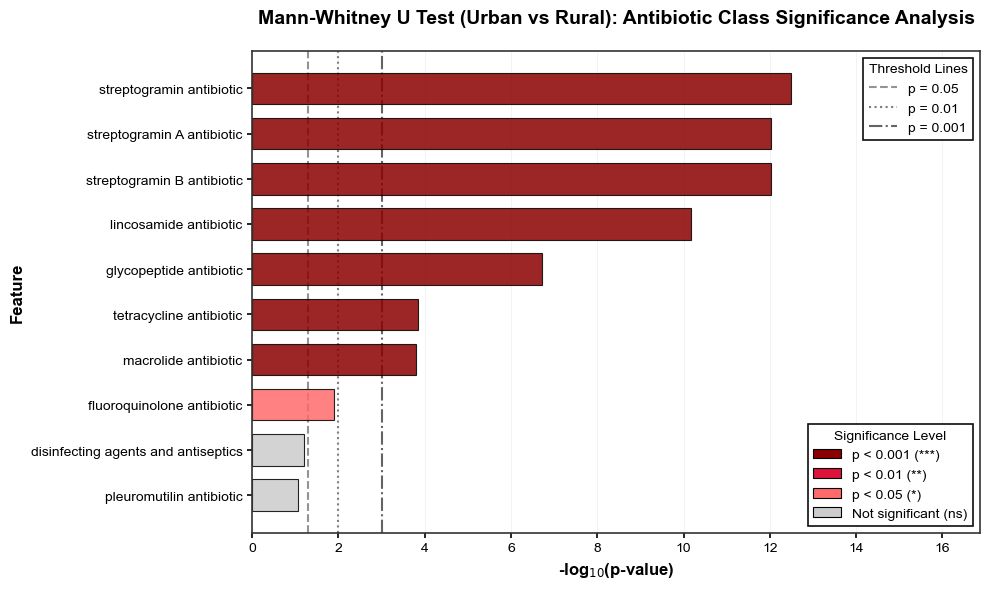

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Configuración global para estilo de publicación
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2

# Preparar datos
plot_df = results_aux.dropna(subset=['p_value']).copy()
plot_df.loc[plot_df['p_value'] == 0, 'p_value'] = np.finfo(float).eps
plot_df['neg_log10_p'] = -np.log10(plot_df['p_value'])

# Umbrales de significancia
p_threshold_05 = 0.05
p_threshold_01 = 0.01
p_threshold_001 = 0.001
log_threshold_05 = -np.log10(p_threshold_05)
log_threshold_01 = -np.log10(p_threshold_01)
log_threshold_001 = -np.log10(p_threshold_001)

# Clasificar significancia con tres niveles
def classify_significance(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

plot_df['sig_level'] = plot_df['p_value'].apply(classify_significance)
plot_df['color_group'] = plot_df['sig_level'].map({
    '***': 'p < 0.001',
    '**': 'p < 0.01',
    '*': 'p < 0.05',
    'ns': 'ns'
})

# Ordenar por significancia
plot_df_sorted = plot_df.sort_values('neg_log10_p', ascending=True)

# Crear figura con mejor tamaño
fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df_sorted) * 0.4)))

# Paleta de colores profesional
colors = {
    'p < 0.001': '#8B0000',  # Rojo oscuro
    'p < 0.01': '#DC143C',   # Crimson
    'p < 0.05': '#FF6B6B',   # Rojo claro
    'ns': '#CCCCCC'          # Gris claro
}

# Crear barras con colores según significancia
y_positions = np.arange(len(plot_df_sorted))
bars = ax.barh(
    y_positions,
    plot_df_sorted['neg_log10_p'],
    height=0.7,
    color=[colors[cat] for cat in plot_df_sorted['color_group']],
    edgecolor='black',
    linewidth=0.8,
    alpha=0.85
)

# Añadir líneas verticales de umbral
ax.axvline(log_threshold_05, color='#666666', linestyle='--', 
           linewidth=1.5, alpha=0.7, zorder=0, label='p = 0.05')
ax.axvline(log_threshold_01, color='#444444', linestyle=':', 
           linewidth=1.5, alpha=0.7, zorder=0, label='p = 0.01')
ax.axvline(log_threshold_001, color='#222222', linestyle='-.', 
           linewidth=1.5, alpha=0.7, zorder=0, label='p = 0.001')

# Añadir anotaciones de p-value al final de cada barra
# for idx, (i, row) in enumerate(plot_df_sorted.iterrows()):
#     # Formato del p-value
#     if row['p_value'] < 0.001:
#         p_text = f"p < 0.001 {row['sig_level']}"
#     elif row['p_value'] < 0.01:
#         p_text = f"p = {row['p_value']:.3f} {row['sig_level']}"
#     else:
#         p_text = f"p = {row['p_value']:.3f} {row['sig_level']}"
    
#     # Posicionar texto
#     x_pos = row['neg_log10_p'] + max(plot_df_sorted['neg_log10_p']) * 0.02
#     ax.text(x_pos, idx, p_text, va='center', ha='left', 
#             fontsize=9, color='#333333', weight='normal')

# Configurar ejes
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df_sorted['feature'], fontsize=10)
ax.set_xlabel('-log$_{10}$(p-value)', fontsize=12, weight='bold')
ax.set_ylabel('Feature', fontsize=12, weight='bold')
ax.set_title('Mann-Whitney U Test (Urban vs Rural): Antibiotic Class Significance Analysis', 
             fontsize=14, weight='bold', pad=20)

# Ajustar límites del eje x para que las anotaciones quepan
max_x = max(plot_df_sorted['neg_log10_p'])
ax.set_xlim(0, max_x * 1.35)

# Grid sutil
ax.grid(axis='x', alpha=0.2, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Leyenda personalizada con niveles de significancia
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors['p < 0.001'], edgecolor='black', 
          linewidth=0.8, label='p < 0.001 (***)'),
    Patch(facecolor=colors['p < 0.01'], edgecolor='black', 
          linewidth=0.8, label='p < 0.01 (**)'),
    Patch(facecolor=colors['p < 0.05'], edgecolor='black', 
          linewidth=0.8, label='p < 0.05 (*)'),
    Patch(facecolor=colors['ns'], edgecolor='black', 
          linewidth=0.8, label='Not significant (ns)')
]

# Primera leyenda para niveles de significancia
legend1 = ax.legend(handles=legend_elements, loc='lower right', 
                    title='Significance Level', frameon=True, 
                    fancybox=False, shadow=False, 
                    framealpha=0.95, edgecolor='black')
legend1.get_frame().set_linewidth(1.2)

# Segunda leyenda para las líneas de umbral
ax.add_artist(legend1)
legend2 = ax.legend(loc='upper right', title='Threshold Lines',
                    frameon=True, fancybox=False, shadow=False,
                    framealpha=0.95, edgecolor='black')
legend2.get_frame().set_linewidth(1.2)

# Spines más profesionales
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color('#333333')

# Ajustar layout
plt.tight_layout()
# plt.show()

# OPCIONAL: Guardar en alta resolución para publicación
plt.savefig(OUTPUTS['figures'] / 'resistance_group_mann_whitney.png', dpi=600, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.savefig(OUTPUTS['figures'] / 'resistance_group_mann_whitney.pdf', 
            bbox_inches='tight', 
            facecolor='white')
plt.savefig(OUTPUTS['figures'] / 'resistance_group_mann_whitney.svg', 
            bbox_inches='tight', 
            facecolor='white')


# plt.savefig(OUTPUTS['figures'] / 'resistance_group_mann_whitney.pdf', bbox_inches='tight', 
#             facecolor='white', edgecolor='none')

In [38]:
classes = list(results_df[results_df['p_value'] < 0.05]['feature'])

In [39]:
df_final_for_plot.columns

Index(['Sample', 'drug class', 'Species', 'count', 'Lifestyle'], dtype='object')

In [40]:
df_to_plot = df_final_for_plot[df_final_for_plot['drug class'].isin(classes)]

In [41]:
df_to_plot

,Sample,drug class,Species,count,Lifestyle
2,36703_3#1,fluoroquinolone antibiotic,Alistipes putredinis,1,Urban
3,36703_3#1,glycopeptide antibiotic,Agathobacter faecis,2,Urban
4,36703_3#1,glycopeptide antibiotic,Alistipes putredinis,1,Urban
5,36703_3#1,glycopeptide antibiotic,Anaerotignum faecicola,1,Urban
6,36703_3#1,glycopeptide antibiotic,Bariatricus comes,3,Urban
...,...,...,...,...,...
3539,37082_3#9,glycopeptide antibiotic,Escherichia coli,1,Rural
3540,37082_3#9,glycopeptide antibiotic,Ruminococcus_E sp003526955,3,Rural
3542,37082_3#9,lincosamide antibiotic,Escherichia coli,1,Rural
3543,37082_3#9,macrolide antibiotic,Escherichia coli,5,Rural


In [42]:
strepto = df_to_plot[df_to_plot['drug class'] == 'tetracycline antibiotic']

In [43]:
strep_rural = list(strepto[strepto['Lifestyle'] == 'Rural']['Species'])
strep_urban = list(strepto[strepto['Lifestyle'] == 'Urban']['Species'])

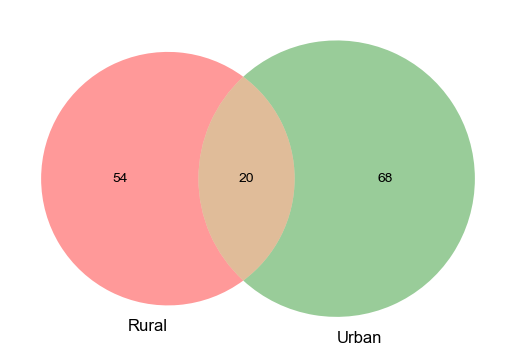

In [44]:
from matplotlib_venn import venn2
set1 = set(strep_rural)
set2 = set(strep_urban)

# Create Venn diagram
venn2([set1, set2], set_labels=('Rural', 'Urban'))

plt.show()

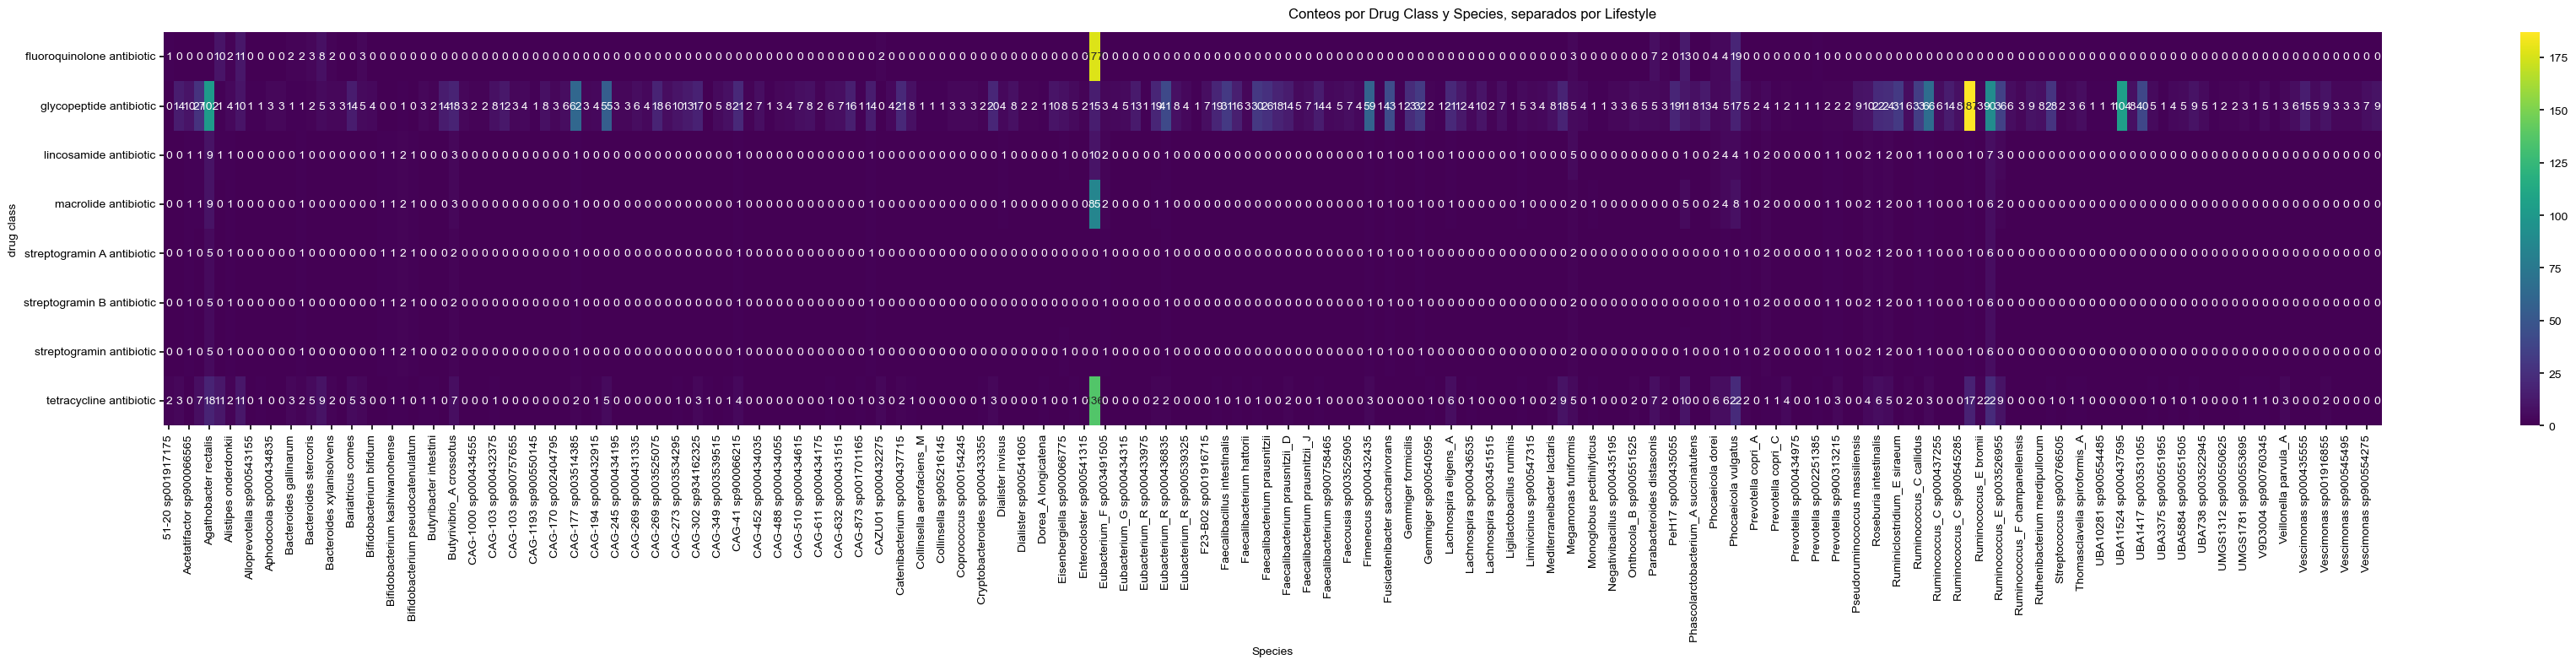

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# --- 2. Crear las matrices de pivote (una para cada lifestyle) ---

# Pivote para 'Urban'
pivot_urban = df_to_plot[df_to_plot['Lifestyle'] == 'Urban'].pivot_table(
    index='drug class',
    columns='Species',
    values='count',
    fill_value=0,
    aggfunc='sum'  # <--- [ARREGLO 1] A&ntilde;adir esto
)

# # Pivote para 'Rural'
# pivot_rural = df_to_plot[df_to_plot['Lifestyle'] == 'Rural'].pivot_table(
#     index='drug class',
#     columns='Species',
#     values='count',
#     fill_value=0,
#     aggfunc='sum'  # <--- [ARREGLO 1] A&ntilde;adir esto
# )

# # --- 3. Graficar los dos heatmaps ---
# fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Gr&aacute;fico 1: Urban
plt.figure(figsize=(35, 8))
sns.heatmap(
    pivot_urban,
    annot=True,
    fmt='.0f',      # <--- [ARREGLO 2] Cambiado de 'd' a '.0f'
    cmap='viridis',
    # ax=axes[0]
)
# axes[0].set_title('Lifestyle: Urban')

# # Gr&aacute;fico 2: Rural
# sns.heatmap(
#     pivot_rural,
#     annot=True,
#     fmt='.0f',      # <--- [ARREGLO 2] Cambiado de 'd' a '.0f'
#     cmap='viridis',
#     ax=axes[1]
# )
# axes[1].set_title('Lifestyle: Rural')

plt.suptitle('Conteos por Drug Class y Species, separados por Lifestyle')
plt.tight_layout()
plt.show()

['streptogramin antibiotic',
 'streptogramin B antibiotic',
 'streptogramin A antibiotic',
 'lincosamide antibiotic',
 'glycopeptide antibiotic',
 'tetracycline antibiotic',
 'macrolide antibiotic',
 'fluoroquinolone antibiotic']

In [46]:
chi2_results_df.sort_values(by='chi2_stat').tail(20)

,feature,chi2_stat,p_value_chi2,p_value_fisher
6,disinfecting agents and antiseptics,NaN,NaN,NaN
7,elfamycin antibiotic,NaN,NaN,NaN
8,fluoroquinolone antibiotic,NaN,NaN,NaN
9,glycopeptide antibiotic,NaN,NaN,NaN
10,glycylcycline,NaN,NaN,NaN
11,lincosamide antibiotic,NaN,NaN,NaN
12,macrolide antibiotic,NaN,NaN,NaN
13,monobactam,NaN,NaN,NaN
16,nitroimidazole antibiotic,NaN,NaN,NaN
17,nucleoside antibiotic,NaN,NaN,NaN


In [47]:
chi2_results_df[chi2_results_df['p_value_chi2'] < 0.01]

,feature,chi2_stat,p_value_chi2,p_value_fisher


In [48]:
chi2_results_df[chi2_results_df['feature'] == 'rifampin']

,feature,chi2_stat,p_value_chi2,p_value_fisher


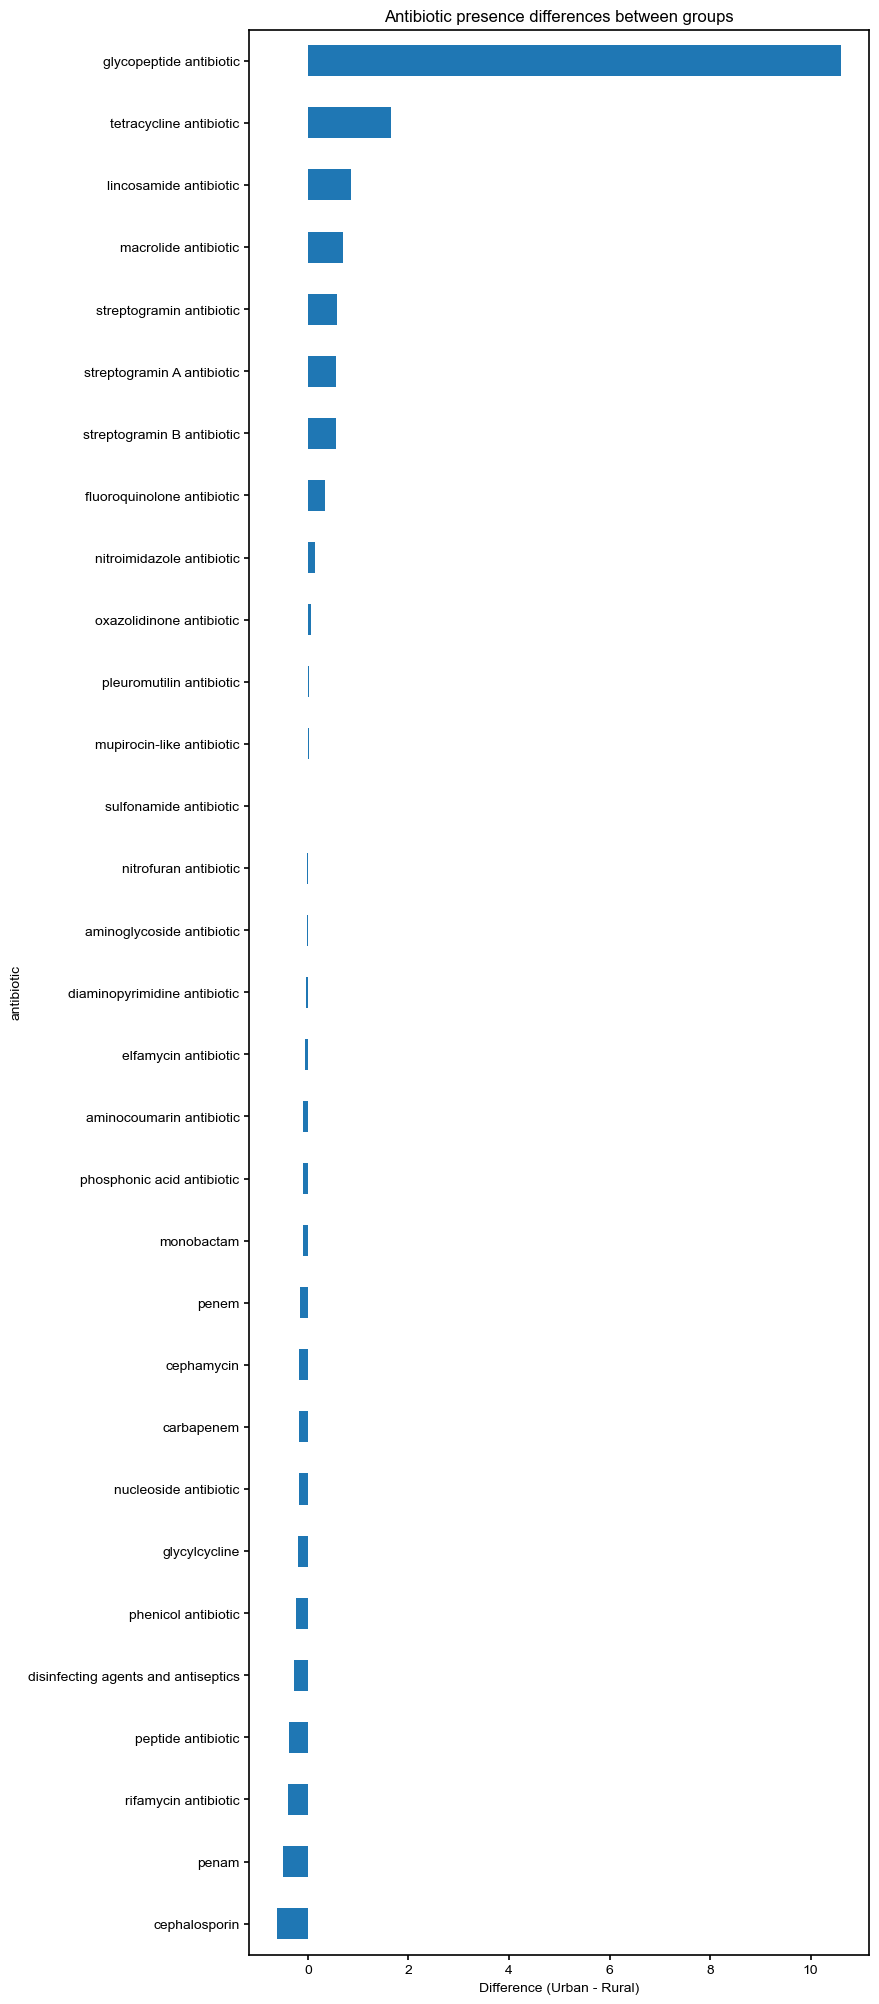

In [49]:
group_means = presence_df.groupby('label').mean().T
group_means['diff'] = group_means['Urban'] - group_means['Rural']
group_means.to_csv(RESISTANCE_TABLES / 'antibiotics_resistance2.csv')
group_means.sort_values('diff', key=abs, ascending=False)
plt.figure(figsize=(8, 25))
group_means['diff'].sort_values().plot(kind='barh')
plt.xlabel('Difference (Urban - Rural)')
plt.title('Antibiotic presence differences between groups')
plt.show()
# print(group_means)

In [50]:
group_means.head()

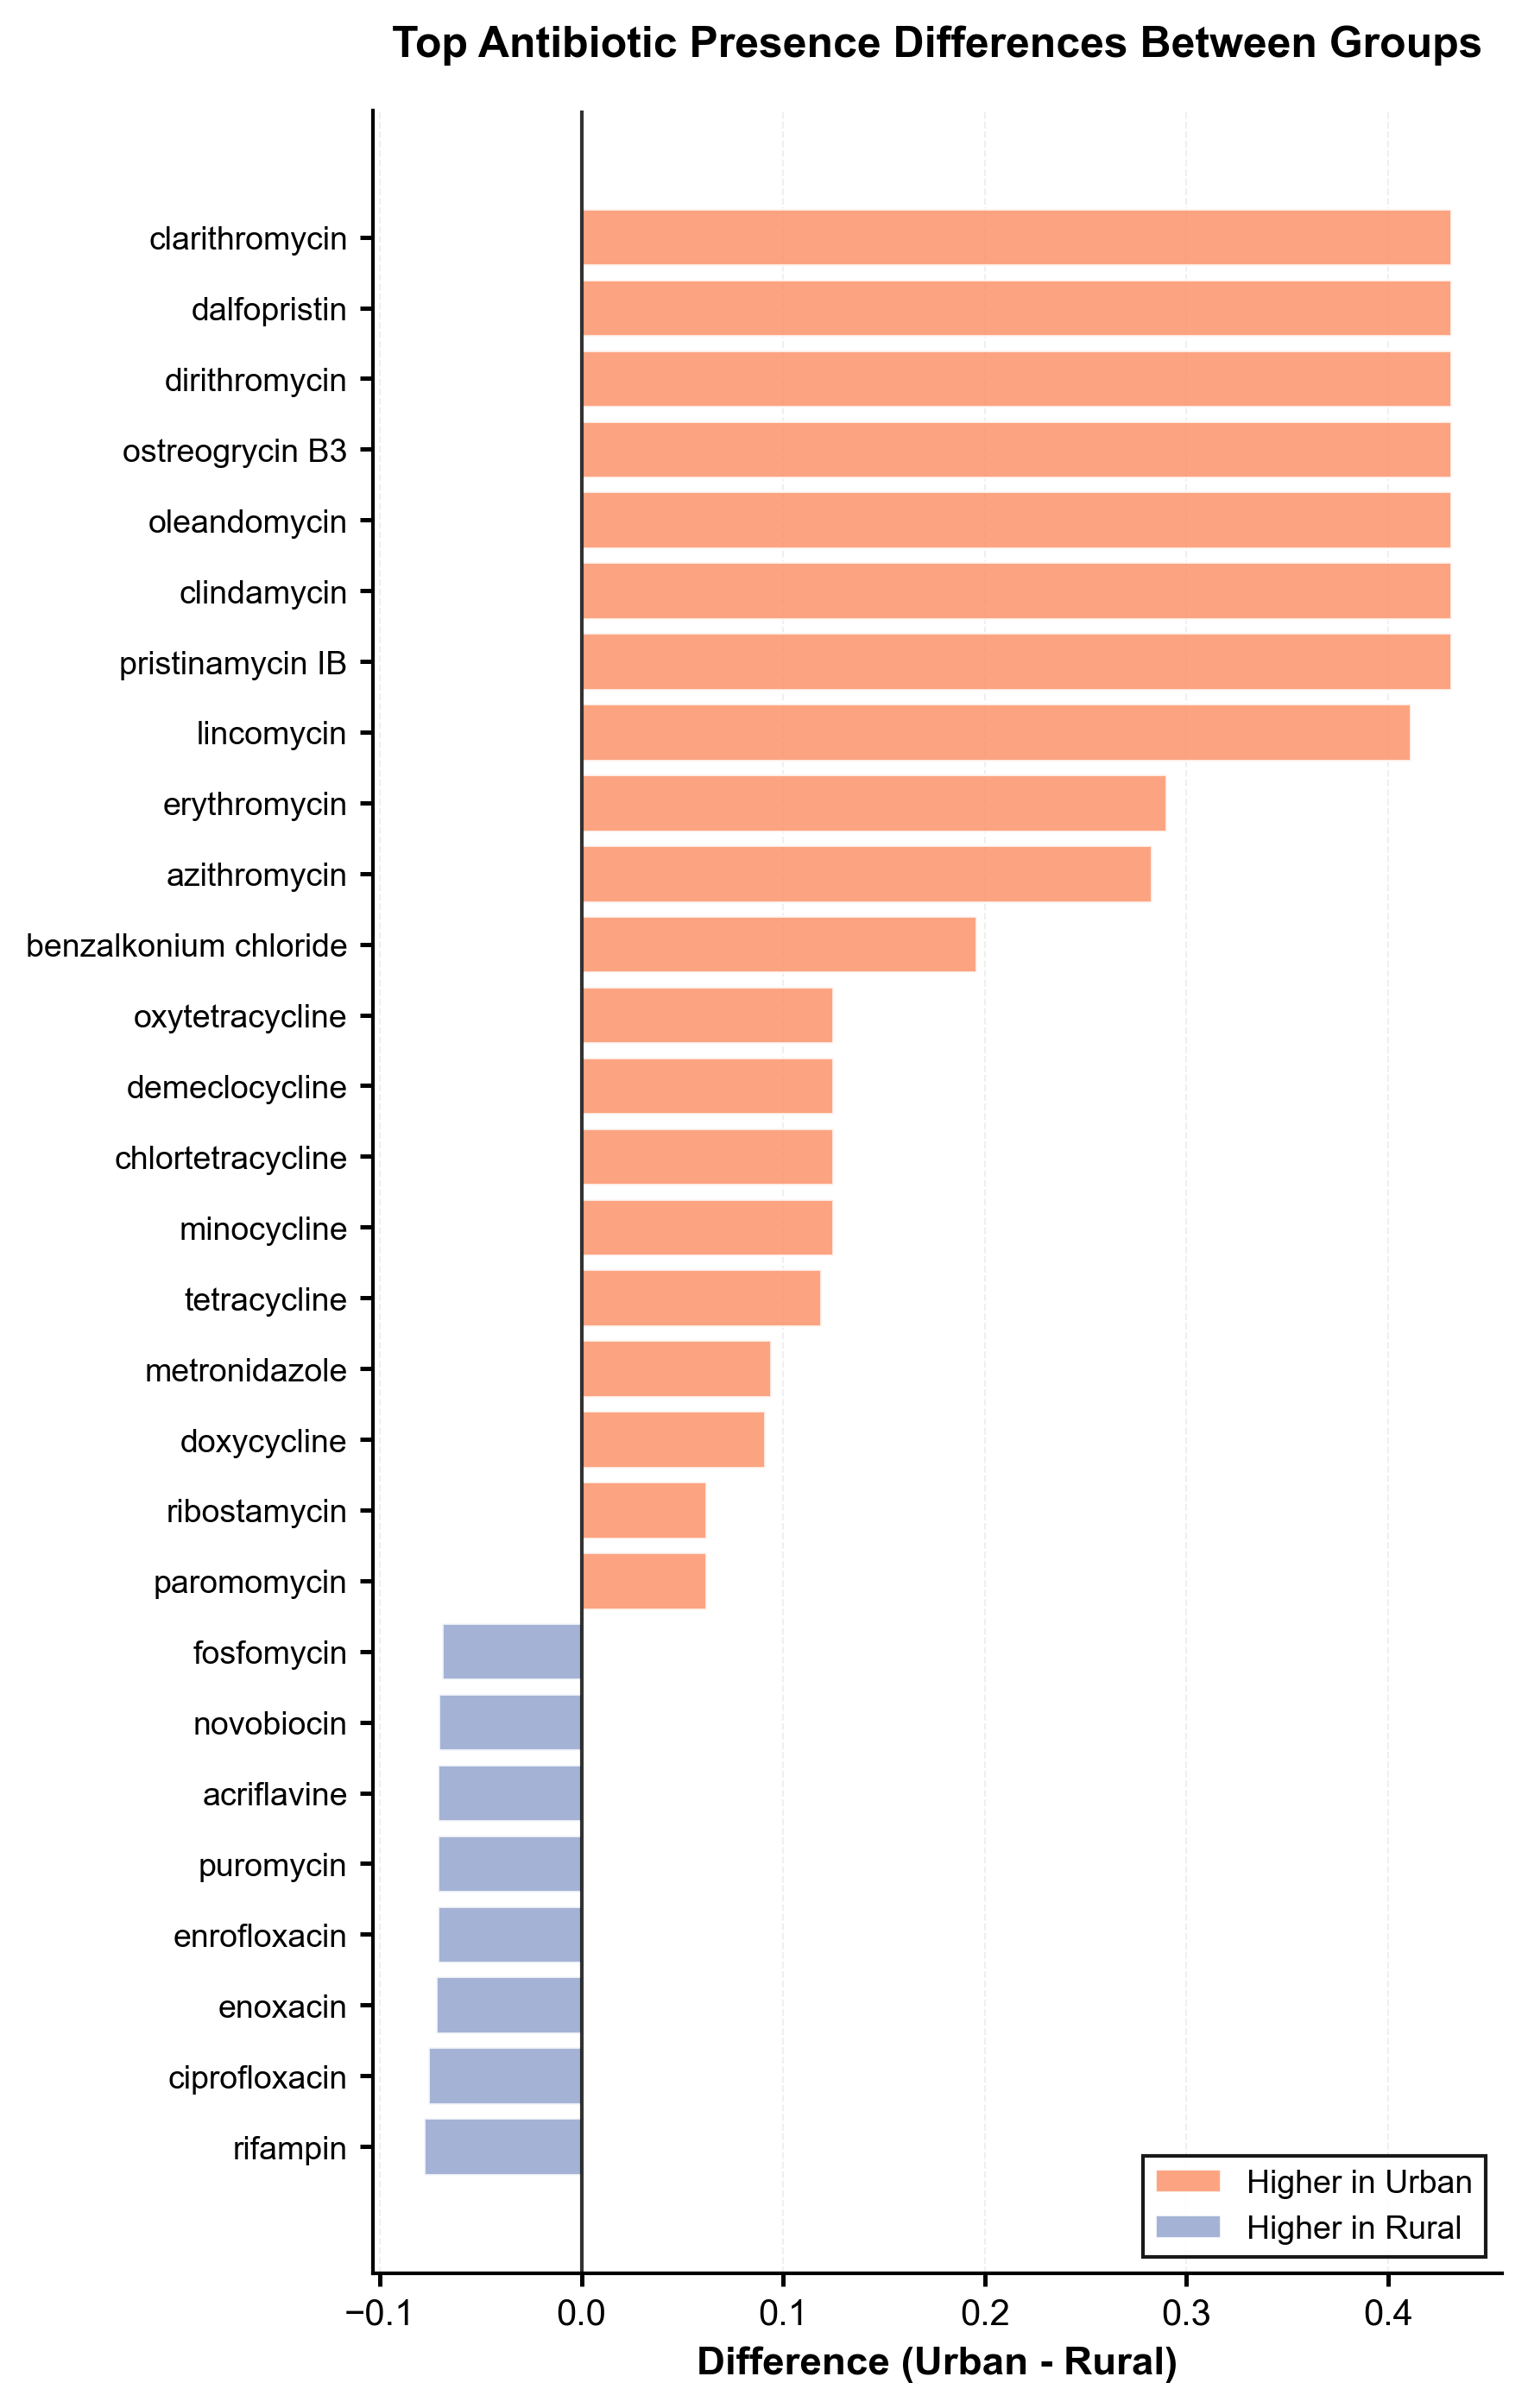

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate group means and differences
# group_means = presence_df.groupby('label').mean().T
group_means['diff'] = group_means['Urban'] - group_means['Rural']

# Filter for differences with absolute value > 0.10
# filtered_means = group_means[np.abs(group_means['diff']) > 0.07].copy()

# Sort by difference
filtered_means_sorted = group_means.sort_values('diff')
filtered_means_sorted = pd.concat([filtered_means_sorted.head(8), filtered_means_sorted.tail(20)])

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0

# Define colors for Urban and Rural
color_urban = plt.cm.Set2.colors[1]  # Orange/coral from Set2
color_rural = plt.cm.Set2.colors[2]  # Green from Set2

# Create colors array: positive = Urban color, negative = Rural color
colors = [color_urban if x > 0 else color_rural for x in filtered_means_sorted['diff']]

# Create figure
fig, ax = plt.subplots(figsize=(6, len(filtered_means_sorted) * 0.3 + 1), dpi=300)

# Create horizontal bar plot
bars = ax.barh(range(len(filtered_means_sorted)), 
               filtered_means_sorted['diff'],
               color=colors,
               alpha=0.8,
               edgecolor='white',
               linewidth=0.7)

# Set y-axis labels
ax.set_yticks(range(len(filtered_means_sorted)))
ax.set_yticklabels(filtered_means_sorted.index, fontsize=9)

# Format axes
ax.set_xlabel('Difference (Urban - Rural)', fontsize=11, fontweight='bold')
ax.set_title('Top Antibiotic Presence Differences Between Groups', 
             fontsize=12, fontweight='bold', pad=15)

# Add vertical line at x=0
ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.8)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, axis='x')
ax.set_axisbelow(True)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_urban, edgecolor='white', linewidth=0.5, label='Higher in Urban', alpha=0.8),
                   Patch(facecolor=color_rural, edgecolor='white', linewidth=0.5, label='Higher in Rural', alpha=0.8)]
ax.legend(handles=legend_elements, 
          loc='lower right',
          frameon=True,
          edgecolor='black',
          fancybox=False,
          framealpha=0.9,
          fontsize=9)

plt.tight_layout()
plt.show()

# Optional: Save figure
# fig.savefig(OUTPUTS['figures'] / 'resistance_antibiotic_group_differences.pdf', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUTS['figures'] / 'resistance_antibiotic_group_differences.png', dpi=400, bbox_inches='tight')

C:\Users\rafap\AppData\Local\Temp\ipykernel_21916\2594346337.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set2')


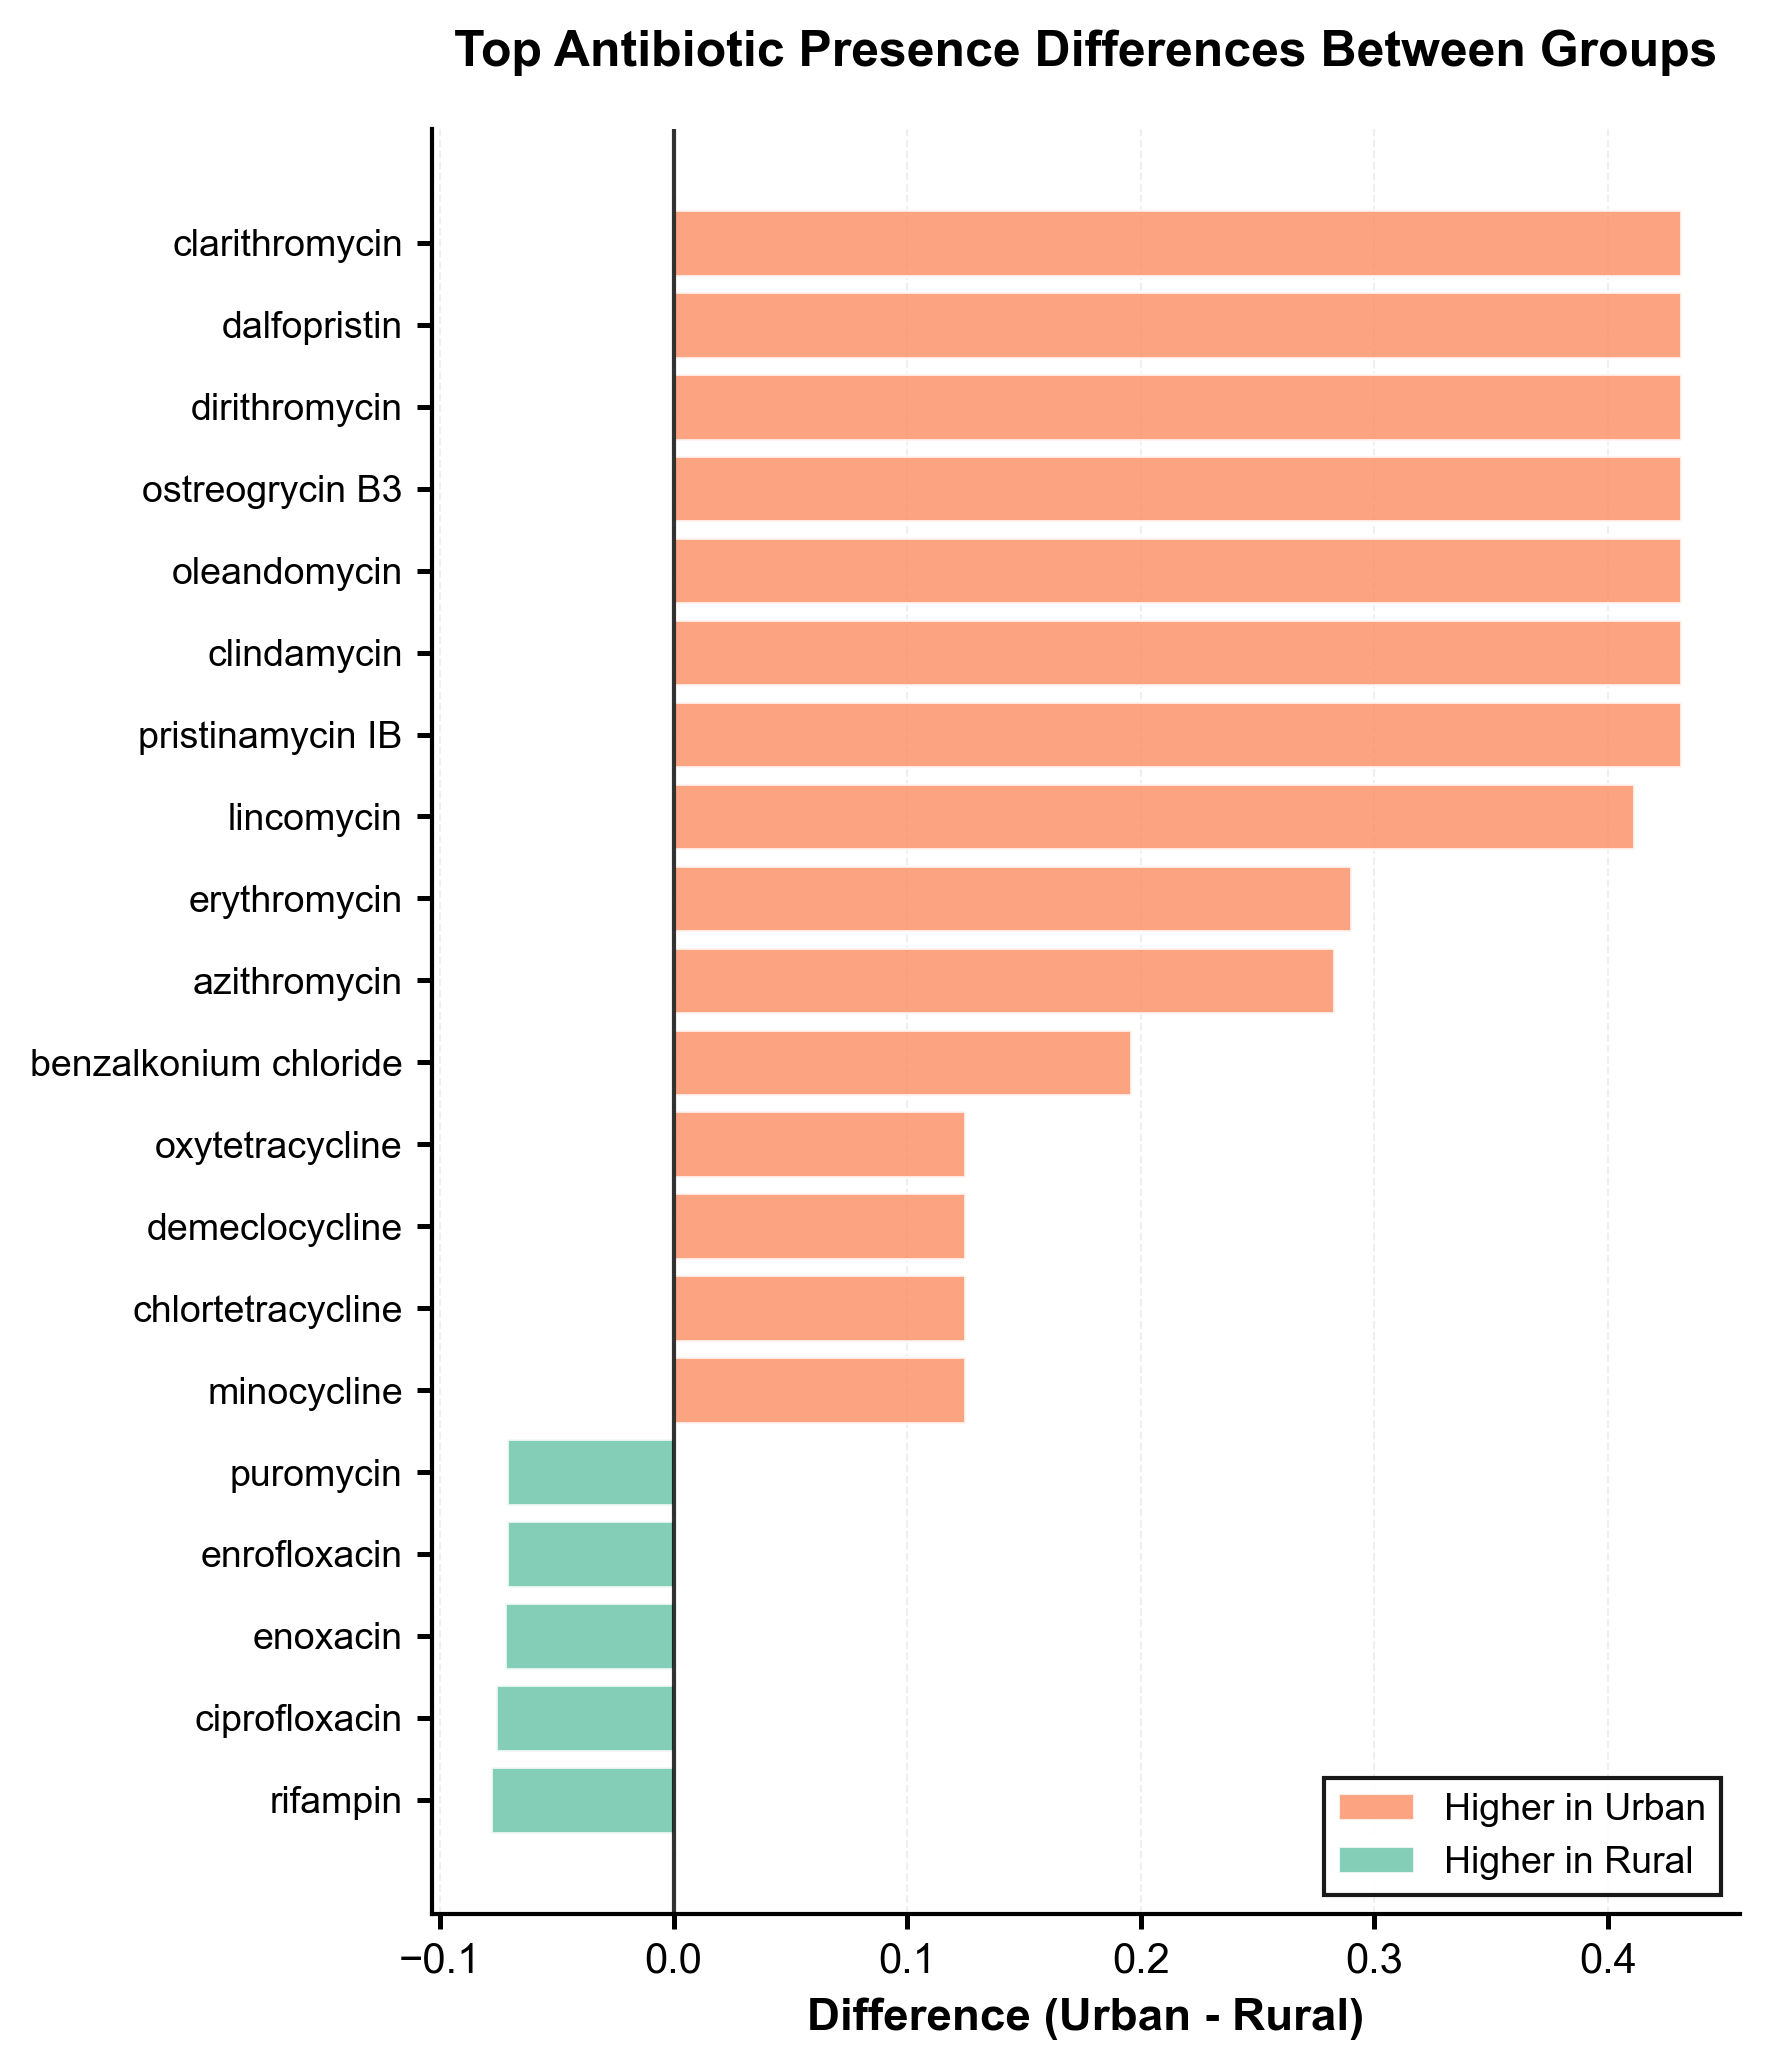

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate group means and differences
group_means['diff'] = group_means['Urban'] - group_means['Rural']

# Sort by difference
filtered_means_sorted = group_means.sort_values('diff')
filtered_means_sorted = pd.concat([filtered_means_sorted.head(5), filtered_means_sorted.tail(15)])

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0

# Define colors for Urban and Rural using Set2 palette (same as working code)
cmap = plt.cm.get_cmap('Set2')
color_urban = cmap.colors[1]   # Orange for Urban (positive = Urban)
color_rural = cmap.colors[0]   # Teal/Green for Rural (negative = Rural)

# Create colors array: positive = Urban color, negative = Rural color
colors = [color_urban if x > 0 else color_rural for x in filtered_means_sorted['diff']]

# Create figure
fig, ax = plt.subplots(figsize=(6, len(filtered_means_sorted) * 0.3 + 1), dpi=300)

# Create horizontal bar plot
bars = ax.barh(range(len(filtered_means_sorted)), 
               filtered_means_sorted['diff'],
               color=colors,
               alpha=0.8,
               edgecolor='white',
               linewidth=0.7)

# Set y-axis labels
ax.set_yticks(range(len(filtered_means_sorted)))
ax.set_yticklabels(filtered_means_sorted.index, fontsize=9)

# Format axes
ax.set_xlabel('Difference (Urban - Rural)', fontsize=11, fontweight='bold')
ax.set_title('Top Antibiotic Presence Differences Between Groups', 
             fontsize=12, fontweight='bold', pad=15)

# Add vertical line at x=0
ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.8)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, axis='x')
ax.set_axisbelow(True)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_urban, edgecolor='white', linewidth=0.5, label='Higher in Urban', alpha=0.8),
                   Patch(facecolor=color_rural, edgecolor='white', linewidth=0.5, label='Higher in Rural', alpha=0.8)]
ax.legend(handles=legend_elements, 
          loc='lower right',
          frameon=True,
          edgecolor='black',
          fancybox=False,
          framealpha=0.9,
          fontsize=9)

plt.tight_layout()
plt.show()

# Save figure
fig.savefig(OUTPUTS['figures'] / 'resistance_antibiotic_group_differences.png', dpi=400, bbox_inches='tight')

In [53]:
# group_means.to_csv(RESISTANCE_TABLES / 'antibiotics_resistance.csv')

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Inicio: Lógica de Agrupación ---

def get_group(antibiotic_name):
    """Asigna un nombre de grupo a un antibiótico basado en palabras clave."""
    name_low = antibiotic_name.lower()
    if 'sulfa' in name_low:
        return 'Sulfonamides (promedio)'
    if 'cillin' in name_low:
        return 'Penicillins (promedio)'
    if 'cycline' in name_low:
        return 'Tetracyclines (promedio)'
    if 'mycin' in name_low: # Agrupa Macrólidos, Aminoglucósidos, etc.
        return 'Grupo ...mycin (promedio)'
    if 'floxacin' in name_low: # Agrupa Quinolonas
        return 'Quinolones (promedio)'
    # Si no pertenece a un grupo, se queda como individual
    return antibiotic_name

# --- Fin: Lógica de Agrupación ---

def create_antibiotic_plot(file_path=RESISTANCE_TABLES / 'antibiotics_resistance.csv', n_items=10):
    """
    Carga los datos, los agrupa, y crea un gráfico de barras horizontales
    mostrando el Top N y Bottom N de las diferencias.
    """
    try:
        # Cargar los datos
        df = pd.read_csv(file_path)

        # 1. Aplicar la función de agrupación
        # df['group'] = df['antibiotic'].apply(get_group)

        # 2. Calcular el promedio de 'diff' para cada grupo
        #    (Los antibióticos individuales tendrán su propio valor como promedio)
        # df_grouped = df.groupby('group')['diff'].mean().reset_index()

        # 3. Renombrar la columna 'group' de nuevo a 'antibiotic' para el plot
        # df_agg = df_grouped.rename(columns={'group': 'antibiotic'})
        
        print(f"Datos originales: {len(df)} antibióticos.")
        print(f"Datos agrupados: {len(df_agg)} items (grupos e individuales).")

        # 4. Obtener el "Top N" (más prevalentes en zona URBANA)
        df_top = df.nlargest(n_items, 'diff')

        # 5. Obtener el "Bottom N" (más prevalentes en zona RURAL)
        df_bottom = df_agg.nsmallest(n_items, 'diff')

        # 6. Combinar los dos grupos
        df_plot = pd.concat([df_top, df_bottom]).drop_duplicates()

        # 7. Ordenar para el gráfico (de más rural a más urbano)
        df_plot = df_plot.sort_values(by='diff', ascending=True)

        # 8. Definir los colores (Paleta "Set2" invertida)
        cmap = plt.cm.get_cmap('Set2')
        # Positivo (Urbano) = Naranja (índice 1 de la paleta)
        color_positive = cmap.colors[1] 
        # Negativo (Rural) = Verde (índice 0 de la paleta)
        color_negative = cmap.colors[0] 

        colors_for_plot = [color_positive if x > 0 else color_negative for x in df_plot['diff']]

        # 9. Crear el gráfico
        num_items_total = len(df_plot)
        # Ajustar la altura dinámicamente
        fig_height = max(10, num_items_total * 0.45 + 2) 
        
        plt.figure(figsize=(12, fig_height))
        
        plt.barh(df_plot['antibiotic'], df_plot['diff'], color=colors_for_plot)

        # 10. Añadir detalles al gráfico
        plt.axvline(x=0, color='grey', linestyle='--')
        plt.xlabel('Diferencia en prevalencia (Proporción Urbana - Proporción Rural)')
        plt.ylabel('Antibiótico o Grupo (promedio)')
        plt.title(f'Top {n_items} (Más Urbanos) y Bottom {n_items} (Más Rurales) por Diferencia (Agrupados)')
        
        # Ajustar el diseño para que no se corten las etiquetas
        plt.tight_layout()

        # 11. Guardar el gráfico
        output_filename = OUTPUTS['figures'] / f'resistance_antibiotic_top_bottom_{n_items}.png'
        plt.savefig(output_filename)

        print(f"\n¡Gráfico guardado exitosamente como: {output_filename}!")
        print(f"Mostrando {num_items_total} items en total.")

    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{file_path}'.")
        print("Por favor, asegúrate de que el archivo esté en el mismo directorio que el script.")
    except Exception as e:
        print(f"Ocurrió un error inesperado: {e}")


In [55]:
create_antibiotic_plot(file_path=RESISTANCE_TABLES / 'antibiotics_resistance2.csv', n_items=10)

Datos originales: 116 antibióticos.
Ocurrió un error inesperado: name 'df_agg' is not defined
